In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from sklearn.preprocessing import MinMaxScaler

In [13]:
def min_max_normalization(data, zero_impute=True):
    contain_na = False
    for omics_data in data:
        if np.isnan(omics_data).any():
            contain_na = True
    # min-max normalization
    if contain_na:
        new_data = []
        omics_min = []
        omics_max = []
        for omics_data in data:
            omics_data = pd.DataFrame(omics_data)
            min_ = omics_data.min()
            max_ = omics_data.max()
            omics_data = (omics_data - min_) / (max_ - min_) + 0.1
            omics_data = np.array(omics_data)

            if zero_impute:
                omics_data[np.abs(omics_data) < 1e-8] = 0.1

            new_data.append(omics_data)
            omics_min.append(np.array(min_))
            omics_max.append(np.array(max_))
    else:
        new_data = []
        omics_min = []
        omics_max = []
        for omics_data in data:
            min_ = omics_data.min()
            max_ = omics_data.max()
            omics_data = (omics_data - min_) / (max_ - min_) + 0.1

            new_data.append(np.array(omics_data))
            omics_min.append(np.array([min_]))
            omics_max.append(np.array([max_]))

    return new_data, omics_min, omics_max

def KNN_impute(matrix):
    data = np.hstack((matrix))
    imputer = KNNImputer()
    KNN_impute_data = imputer.fit_transform(data)
    if data.shape != KNN_impute_data.shape:
        print("Skip KNN preimpute because of the all-zero features.")

        return matrix

    split_list = [0]
    for each in matrix:
        split_list.append(each.shape[1] + split_list[-1])
    matrix = np.split(KNN_impute_data, split_list[1:-1], axis=1)

    return matrix

def preprocess(matrix, normalization=True, pre_impute=False):
        # min-max normizaltion
    if normalization:
        matrix, omics_min, omics_max = min_max_normalization(data=matrix, zero_impute=False)
        matrix = np.array(matrix)

    # KNN preimpute
    if pre_impute:
        matrix = KNN_impute(matrix)
        matrix = np.array(matrix)

    return matrix


In [ ]:
def save_edges_and_weights(save_dir, edges, weights, train_size, normalization):
    # Normalize 会让本来没有0的数据集产生零，即本来的最小值会变成0
    save_dir = Path(save_dir)
    nums_type = edges.max(0) + 1

    weights = weights.reshape(-1, 1)

    if normalization:
        scaler = MinMaxScaler()
        weights = scaler.fit_transform(weights)
        print('Normalize', scaler)

    train_data, test_data, train_weight, test_weight = train_test_split(edges, weights, train_size=train_size)
    train_weight = train_weight.reshape(-1)
    test_weight = test_weight.reshape(-1)

    np.savez(save_dir / 'train_data.npz', train_data=train_data, train_weight=train_weight,
             nums_type=nums_type)
    np.savez(save_dir / 'test_data.npz', test_data=test_data, test_weight=test_weight,
             nums_type=nums_type)


def save_metadata(save_dir, edges, train_size, nums_type, normalization):
    metadata = dict(
        train_size=train_size,
        normalization=normalization,
        num_edges=edges.shape[0],
        num_nodes=sum(nums_type),
        num_cells=nums_type[0],
        num_genes=nums_type[1],
        num_omics=nums_type[2],
    )
    np.savez(save_dir / 'metadata', **metadata)


## sc-GEM

In [20]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [46]:
len(labels)

224

In [ ]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [88]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

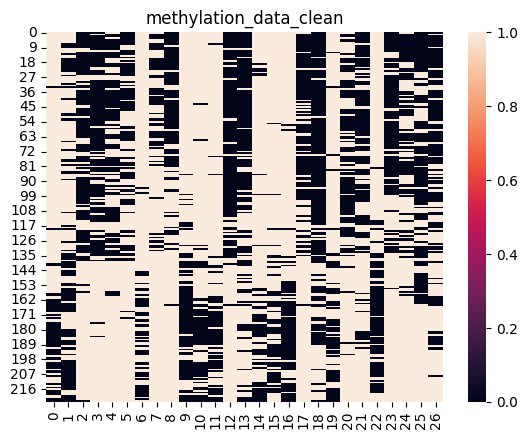

In [89]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

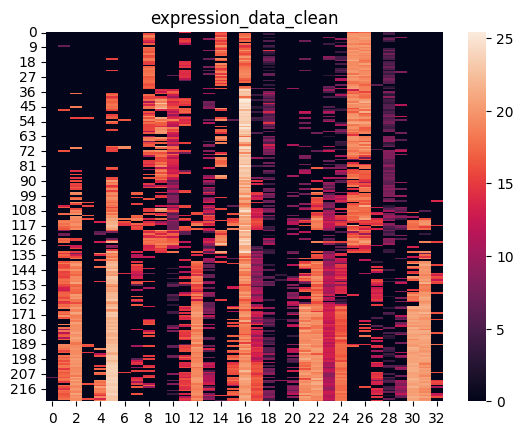

In [90]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [104]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(data)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [105]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [106]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [107]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [108]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [109]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [110]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [111]:
np.any(weights == 0)

False

In [112]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [113]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [114]:
np.any(train_data['train_weight'] == 0)

False

In [115]:
np.any(test_data['test_weight'] == 0)

False

In [116]:
train_data['nums_type']

array([224,  60,   2])

In [117]:
!python hgnn/main_torch.py --data sc_GEM

1.0 -0.5
model_no_randomwalk
Use train_weight
Node type num [224  60   2]
H.shape [(224, 5444), (60, 5444), (2, 5444)]
embeddings.shape [(224, 286), (60, 286), (2, 286)]
[ 1.       18.701824  5.968821 ...  1.       23.512575  1.      ] 1.0 25.435984
walk type 
adding pad idx
dict_size 5444 6805
train data amount 5444
64
tensor([  0, 224, 284, 286], device='cuda:0')
w.shape (224, 62)
(224, 62)
w.shape (60, 226)
(60, 226)
w.shape (2, 284)
(2, 284)
self.input_size [62, 226, 284]
inp 62 out 64 weight.shape torch.Size([64, 62])
fan_in 62 7.874007874011811
inp 226 out 64 weight.shape torch.Size([64, 226])
fan_in 226 15.033296378372908
inp 284 out 64 weight.shape torch.Size([64, 284])
fan_in 284 16.852299546352718
save embeddings
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]]               0
         LayerNorm-2                [-1, 3, 64] 

In [118]:
cell_embeddings = np.load('./mymodel_0.npy', allow_pickle=True)

In [121]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 57K Nov 10 11:02 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 57K Nov 10 11:02 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs 16K Nov 10 11:02 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs 16K Nov 10 11:02 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 11:02 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 11:02 ./mymodel_2_origin.npy


In [120]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.5259665225188815,
 'ARI': 0.37100467820158595,
 'FMI': 0.4556849173028106}

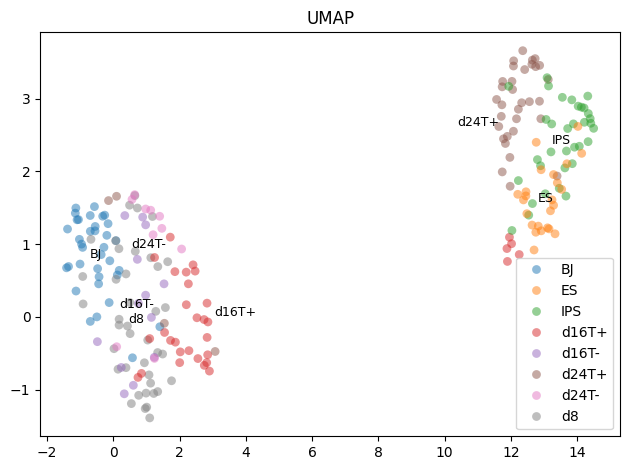

In [122]:
umap_visualize(cell_embeddings, labels)